# SentiNet-VA Norfolk Pilot — Exploratory Data Analysis

## A transparent data-foundation review for traffic-safety prioritization

**Central question:** When resources are limited, where should Norfolk look first for potential traffic-safety improvements?

This notebook evaluates the historical crash-data foundation used by SentiNet-VA before ranking or visualization. It is exploratory: it describes recorded crashes, not future risk, causality, enforcement need, or the suitability of a specific intervention.

**Study window:** 2016-01-01 through 2025-12-31  
**Geography:** Norfolk, Virginia (approved 2025 Census county-equivalent boundary; GEOID 51710)  
**Sources:** City of Norfolk crash-data snapshot supplied with this repository; NCES EDGE public/private school locations (2023–24).

### Transparency commitments

- Every visualization reports observed records; it is not a crash-rate analysis because a complete exposure denominator is unavailable.
- A 250 m grid is only a reproducible analytic location proxy. It is not an intersection, legal school zone, or deployment unit.
- NCES school points are reported facility locations, not attendance boundaries or legal school zones.
- Missingness, coordinate exclusions, and ambiguous coding are shown rather than silently corrected.

## 1. Setup and data loading

The notebook discovers the repository root automatically and reads the local source snapshots. It can be rerun from the `pilot study` directory without hard-coded user paths. The configuration file provides source metadata, coordinate reference systems, and the approved validation envelope.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.labelsize": 11})

try:
    import folium
    from folium.plugins import HeatMap
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False

# Approximate local metric conversion used only for transparent 250 m grid and
# straight-line school-distance screening. It avoids requiring a GIS runtime.
def local_meters(longitude, latitude, ref_lon=-76.285, ref_lat=36.87):
    x = (np.asarray(longitude) - ref_lon) * 111_320 * np.cos(np.deg2rad(ref_lat))
    y = (np.asarray(latitude) - ref_lat) * 110_540
    return x, y

def find_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "Norfolk" / "Traffic_Crashes.csv").exists():
            return candidate
    raise FileNotFoundError("Cannot find data/Norfolk/Traffic_Crashes.csv. Set REPO_ROOT manually.")

REPO_ROOT = find_root()
DATA = REPO_ROOT / "data" / "Norfolk"
CRASH_PATH = DATA / "Traffic_Crashes.csv"
PUBLIC_PATH = DATA / "NCES_Public_Schools_2023_24.csv"
PRIVATE_PATH = DATA / "NCES_Private_Schools_2023_24.csv"
with (REPO_ROOT / "configs" / "norfolk_pilot.json").open(encoding="utf-8") as f:
    config = json.load(f)

crashes_raw = pd.read_csv(CRASH_PATH, low_memory=False)
public_raw = pd.read_csv(PUBLIC_PATH, low_memory=False)
private_raw = pd.read_csv(PRIVATE_PATH, low_memory=False)
print(f"Repository root: {REPO_ROOT}")
print(f"Crash snapshot: {len(crashes_raw):,} rows × {crashes_raw.shape[1]} columns")
display(crashes_raw.head(3))

Repository root: D:\Github Projects\Sentinel-VA\Sentinel-VA
Crash snapshot: 42,004 rows × 55 columns


,Document Number,Datetime,Route or Street Name,Number of Vehicles Involved,Crash Severity,Number of Fatalities,Number of People with Suspected Serious Injury,Number of People with Suspected Minor Injury,Number of People with Possible Injury,Number of People Injured,...,Roadway Description,Intersection Type,Traffic Control Type,Traffic Control Device Status,Owner of Roadway,Latitude,Longitude,Ward,Superward,Civic League
0,161915029,"June 30, 2016 04:43 PM",EASTBOUND INTERSTATE 64,2,Property Damage Only,0,0,0,0,0,...,"Two-Way, Divided, Positive Median Barrier",Not at Intersection,Traffic Lanes Marked,Yes - Working,State Hwy Agency,36.837598,-76.196233,4.0,7.0,River Forrest Shores/ Wayside Manor
1,163545492,"December 19, 2016 04:08 PM",I-64 WESTBOUND,2,Visible Injury,0,0,1,0,1,...,"Two-Way, Divided, Unprotected Median",Not at Intersection,Traffic Lanes Marked,Yes - Working,State Hwy Agency,36.950987,-76.265189,5.0,6.0,Ocean View
2,161805014,"June 27, 2016 09:45 PM",INTERSTATE 264 (WEST),2,Property Damage Only,0,0,0,0,0,...,"Two-Way, Divided, Positive Median Barrier",Not at Intersection,Traffic Lanes Marked,Yes - Working,State Hwy Agency,36.845993,-76.184880,4.0,7.0,NaN


### Source and data-dictionary note

The crash snapshot is a historical administrative record. A missing flag is not proof that a condition was absent, and changes in reporting or coding can affect year-to-year comparisons. The repository configuration identifies the source owner, acquisition date, CRS (EPSG:4326), and known limitations. Before public release, cite the provider’s original data dictionary/source URL; this local snapshot does not include a formal data dictionary.

## 2. Dataset overview and feature preparation

The following prepares analysis fields without changing source columns. Descriptive temporal charts use valid timestamps in 2016–2025. Spatial charts additionally require a coordinate inside the documented conservative validation envelope. Production use must apply the approved boundary predicate (`covers`), not this envelope alone.

In [2]:
YES = {"yes", "y", "true", "1", "involved"}
def yes_flag(s): return s.astype("string").str.strip().str.lower().isin(YES)
def number(name): return pd.to_numeric(crashes_raw[name], errors="coerce").fillna(0)

crashes = crashes_raw.copy()
crashes["crash_datetime"] = pd.to_datetime(crashes["Datetime"], errors="coerce")
for name, accessor in {"year":"year", "month":"month", "quarter":"quarter", "hour":"hour", "dow":"dayofweek"}.items():
    crashes[name] = getattr(crashes["crash_datetime"].dt, accessor)
crashes["day_name"] = crashes["crash_datetime"].dt.day_name()
crashes["is_weekend"] = crashes["dow"].isin([5, 6])
crashes["latitude"] = pd.to_numeric(crashes["Latitude"], errors="coerce")
crashes["longitude"] = pd.to_numeric(crashes["Longitude"], errors="coerce")
crashes["pedestrian_involved"] = yes_flag(crashes["Pedestrian Involved"])
crashes["bicycle_involved"] = yes_flag(crashes["Bicycle Involved"])
crashes["vru_involved"] = crashes["pedestrian_involved"] | crashes["bicycle_involved"]
for target, source in [("fatalities", "Number of Fatalities"), ("injuries", "Number of People Injured"), ("serious_injuries", "Number of People with Suspected Serious Injury")]:
    crashes[target] = number(source)
crashes["study_window"] = crashes["year"].between(2016, 2025)
env = config["validation_envelope"]
crashes["has_coordinate"] = crashes[["latitude", "longitude"]].notna().all(axis=1)
crashes["valid_envelope_coordinate"] = crashes.latitude.between(env["min_latitude"], env["max_latitude"]) & crashes.longitude.between(env["min_longitude"], env["max_longitude"])
study = crashes.loc[crashes.study_window & crashes.crash_datetime.notna()].copy()
geo_study = study.loc[study.valid_envelope_coordinate].copy()

overview = pd.DataFrame({"Metric": ["Raw crash records", "Valid-dated records, 2016–2025", "Envelope-valid spatial records", "Distinct severity labels", "Earliest valid timestamp", "Latest valid timestamp"], "Value": [len(crashes), len(study), len(geo_study), study["Crash Severity"].nunique(), study.crash_datetime.min(), study.crash_datetime.max()]})
display(overview)

key = ["Datetime", "Document Number", "Crash Severity", "Type of Collision", "Pedestrian Involved", "Bicycle Involved", "Number of Fatalities", "Number of People Injured", "Latitude", "Longitude", "Route or Street Name", "School Zone"]
schema = pd.DataFrame({"Field":key, "Source dtype":[str(crashes_raw[c].dtype) for c in key], "Non-null":[crashes_raw[c].notna().sum() for c in key], "Example values":[" | ".join(crashes_raw[c].dropna().astype(str).unique()[:3]) for c in key]})
display(schema)

C:\Users\shahe\AppData\Local\Temp\ipykernel_14928\1787014962.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crashes["crash_datetime"] = pd.to_datetime(crashes["Datetime"], errors="coerce")


,Metric,Value
0,Raw crash records,42004
1,"Valid-dated records, 2016–2025",42004
2,Envelope-valid spatial records,42004
3,Distinct severity labels,5
4,Earliest valid timestamp,2016-01-01 02:45:00
5,Latest valid timestamp,2025-12-31 23:25:00


,Field,Source dtype,Non-null,Example values
0,Datetime,object,42004,"June 30, 2016 04:43 PM | December 19, 2016 04:..."
1,Document Number,int64,42004,161915029 | 163545492 | 161805014
2,Crash Severity,object,42004,Property Damage Only | Visible Injury | Nonvis...
3,Type of Collision,object,42004,Rear End | Fixed Object - Off Road | Angle
4,Pedestrian Involved,object,42004,No | Yes
5,Bicycle Involved,object,42004,No | Yes
6,Number of Fatalities,int64,42004,0 | 1 | 3
7,Number of People Injured,int64,42004,0 | 1 | 3
8,Latitude,float64,42004,36.83759777013 | 36.95098742601 | 36.84599349943
9,Longitude,float64,42004,-76.19623279506 | -76.2651894949 | -76.1848797689


## 3. Missing data and data quality

No imputation is applied. A source field may support a descriptive count but not a negative inference when missingness is material: for example, blank VRU flags are treated as not affirmative for count calculations, while their missingness remains visible below.

In [3]:
missing = crashes_raw.isna().sum().to_frame("missing_count")
missing["missing_pct"] = 100 * missing.missing_count / len(crashes_raw)
display(missing.sort_values("missing_pct", ascending=False).style.format({"missing_pct":"{:.1f}%"}).bar(subset=["missing_pct"], color="#d95f02"))

quality = pd.DataFrame({"Check": ["Unparseable/missing timestamp", "Date outside 2016–2025", "Missing coordinate", "Outside coordinate envelope", "Missing pedestrian flag", "Missing bicycle flag", "Negative fatalities/injuries", "Duplicate document-number records"], "Records": [crashes.crash_datetime.isna().sum(), (crashes.crash_datetime.notna() & ~crashes.study_window).sum(), (~crashes.has_coordinate).sum(), (crashes.has_coordinate & ~crashes.valid_envelope_coordinate).sum(), crashes_raw["Pedestrian Involved"].isna().sum(), crashes_raw["Bicycle Involved"].isna().sum(), ((crashes.fatalities < 0) | (crashes.injuries < 0)).sum(), crashes_raw["Document Number"].duplicated(keep=False).sum()]})
display(quality)

for col in ["Crash Severity", "Pedestrian Involved", "Bicycle Involved", "School Zone", "Night Crash"]:
    print(f"\n{col}")
    display(crashes_raw[col].value_counts(dropna=False).head(15).to_frame("records"))

,missing_count,missing_pct
Maximum Speed Difference,32017,76.2%
Civic League,19555,46.6%
Ward,203,0.5%
Superward,197,0.5%
Driver Action,6,0.0%
Vehicle Maneuver,6,0.0%
Direction of Travel,6,0.0%
Most Harmful Crash Event,6,0.0%
Number of Fatalities,0,0.0%
Crash Severity,0,0.0%


,Check,Records
0,Unparseable/missing timestamp,0
1,Date outside 2016–2025,0
2,Missing coordinate,0
3,Outside coordinate envelope,0
4,Missing pedestrian flag,0
5,Missing bicycle flag,0
6,Negative fatalities/injuries,0
7,Duplicate document-number records,0



Crash Severity


,records
Crash Severity,
Property Damage Only,27324
Visible Injury,10550
Nonvisible Injury,2286
Severe Injury,1634
Fatal Injury,210



Pedestrian Involved


...

,records
Bicycle Involved,
No,41665
Yes,339



School Zone


,records
School Zone,
No,41290
Yes,557
Yes - With School Activity,134
Not Applicable,23



Night Crash


,records
Night Crash,
No,31047
Yes,10957


### Field-use recommendation

| Field group | Use | Limitation |
|---|---|---|
| Timestamp and crash count | Use after parsing and window filtering | Examine partial years and unparseable dates. |
| Coordinates | Use after approved-boundary validation | Envelope is a diagnostic, not a legal boundary. |
| Pedestrian / bicycle flags | Count explicit affirmatives | Missing or unknown does not confirm vehicle-only status. |
| Street / crash type / contributing factors | Group for review | Normalize labels before production matching. |
| School distance | Proximity signal | Not a school-zone, attendance-boundary, or exposure measure. |

## 4. Crash burden: frequency, severity, and spatial concentration

Annual and severity charts use valid-dated study records. Spatial displays use envelope-valid coordinates. Counts should identify locations for review, not be interpreted as risk per traveler.

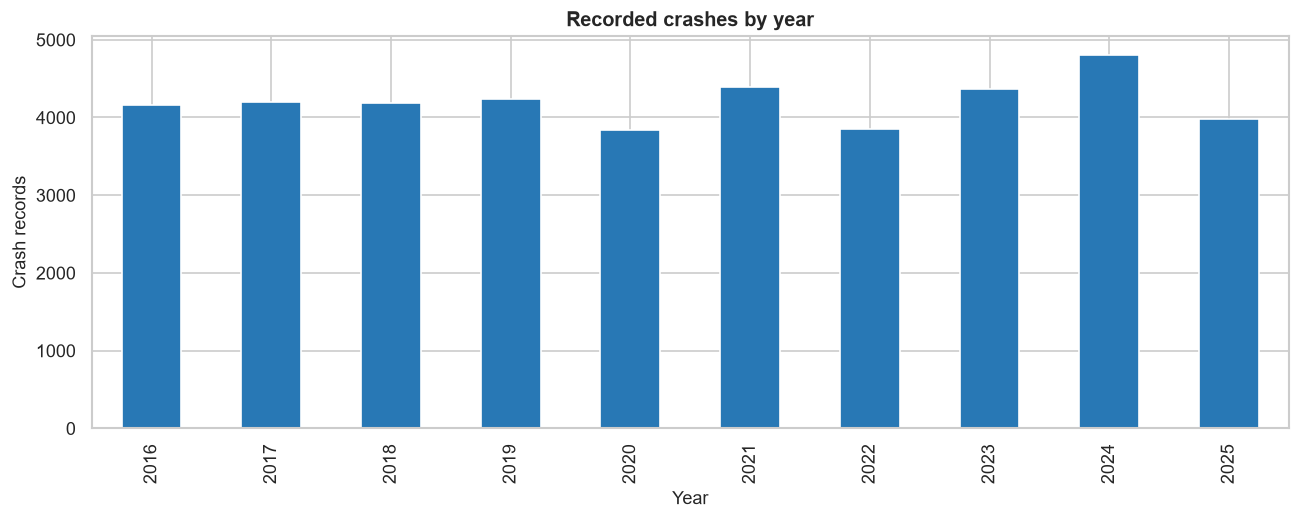

,crashes,injuries,fatalities
year,,,
2016,4163,2581,18
2017,4195,2296,20
2018,4185,2146,16
2019,4240,2220,24
2020,3837,2022,25
2021,4388,2249,28
2022,3845,1978,23
2023,4367,2245,15
2024,4805,2094,20


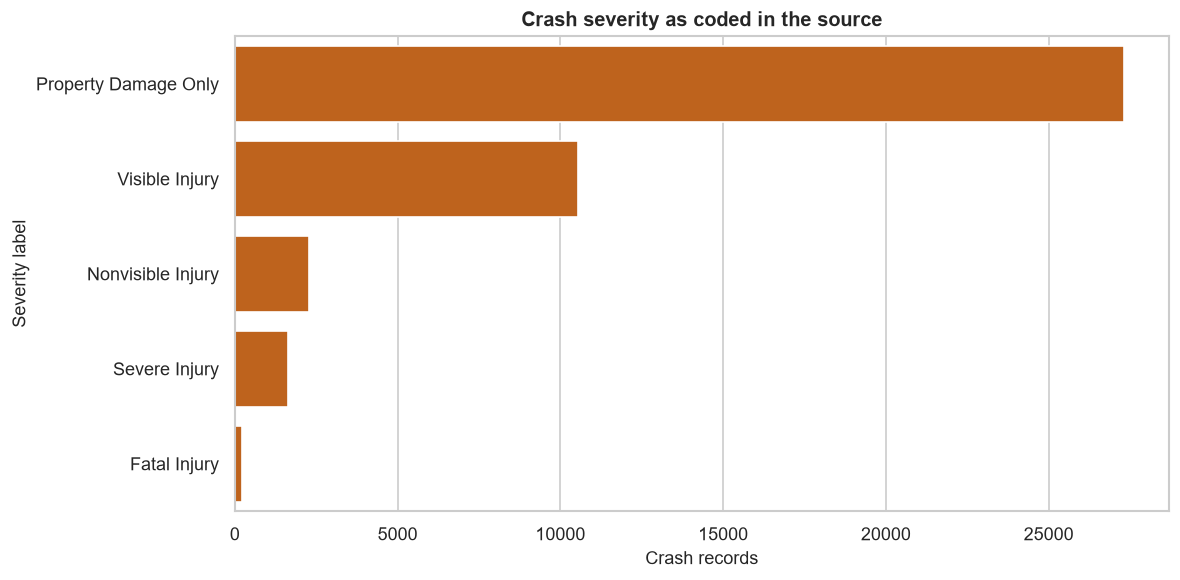

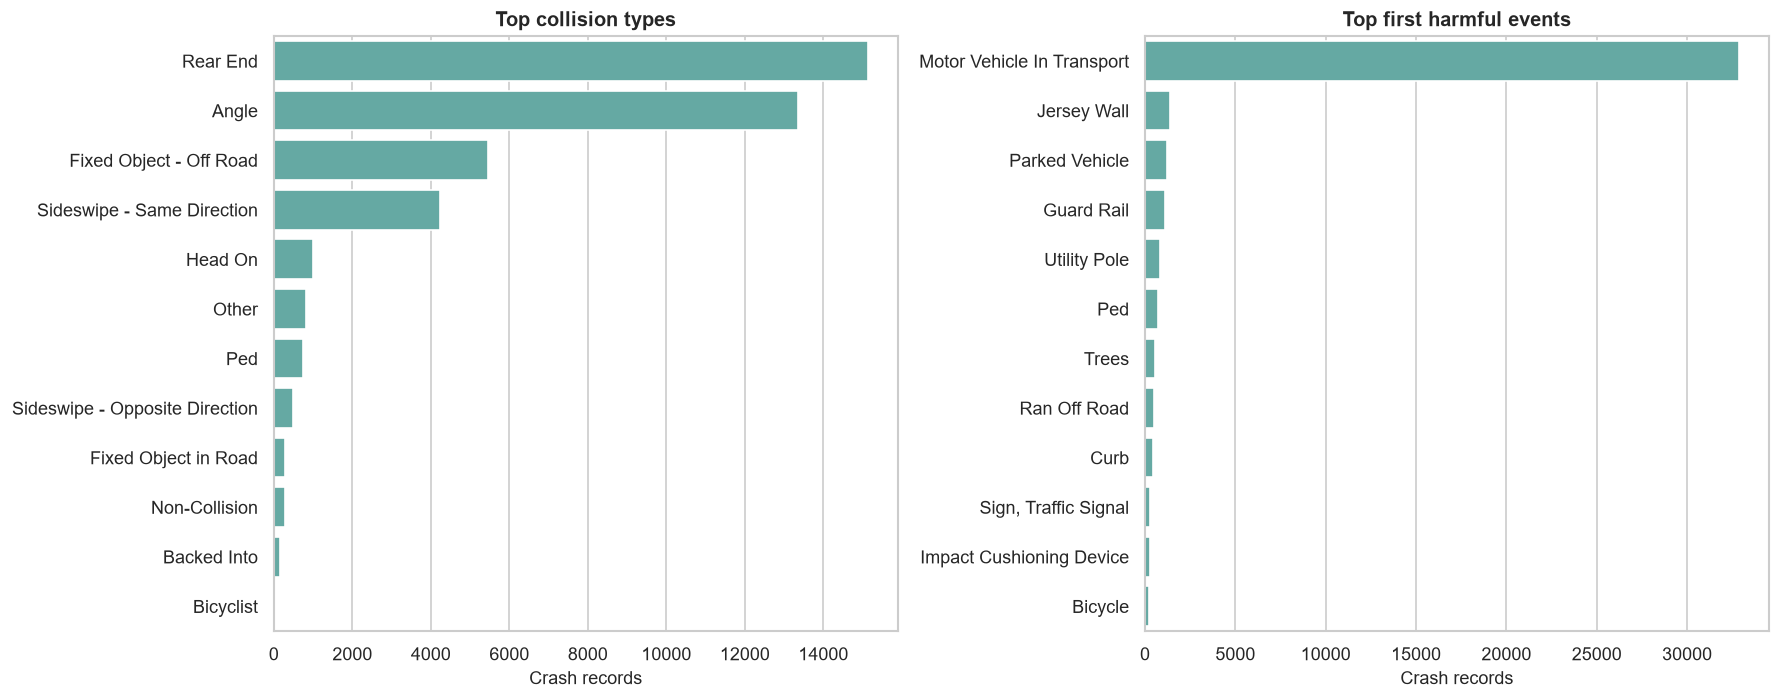

In [4]:
yearly = study.groupby("year").agg(crashes=("Document Number","size"), injuries=("injuries","sum"), fatalities=("fatalities","sum")).reindex(range(2016,2026), fill_value=0)
fig, ax = plt.subplots(figsize=(11,4.5)); yearly.crashes.plot.bar(ax=ax, color="#2878b5")
ax.set(title="Recorded crashes by year", xlabel="Year", ylabel="Crash records"); plt.tight_layout(); plt.show(); display(yearly)

severity = study["Crash Severity"].fillna("Missing / unknown").value_counts()
fig, ax = plt.subplots(figsize=(10,5)); sns.barplot(x=severity.values, y=severity.index, ax=ax, color="#d95f02")
ax.set(title="Crash severity as coded in the source", xlabel="Crash records", ylabel="Severity label"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1,2,figsize=(15,6))
for ax, col, title in zip(axes, ["Type of Collision","First Harmful Event"], ["Top collision types","Top first harmful events"]):
    s = study[col].fillna("Missing / unknown").value_counts().head(12)
    sns.barplot(x=s.values, y=s.index, ax=ax, color="#5ab4ac"); ax.set(title=title, xlabel="Crash records", ylabel="")
plt.tight_layout(); plt.show()

,crashes,fatalities,injuries,pedestrian_crashes,bicycle_crashes,latitude,longitude,street_example
location_id,,,,,,,,
G31_-9,509,0,213,0,0,36.850817,-76.196195,I-64 WEST
G31_-7,384,0,205,1,1,36.854854,-76.195956,POPLAR HALL DR
G0_0,380,2,229,6,6,36.870720,-76.283283,2600 BLK OMOHUNDRO AVE
G31_-8,330,0,147,0,0,36.853110,-76.196061,I-64 EAST
G31_-11,318,1,131,1,0,36.846235,-76.196441,I-64 EAST
G35_-11,313,0,127,0,0,36.845993,-76.185104,INTERSTATE 264 (WEST)
G15_19,304,0,215,7,6,36.914661,-76.241421,7800 CHESAPEAKE BLVD
G10_15,300,1,203,1,0,36.904904,-76.256276,INTERSTATE 64 WEST BOUND
G-1_-14,294,0,120,1,0,36.839397,-76.286876,WEST I-264


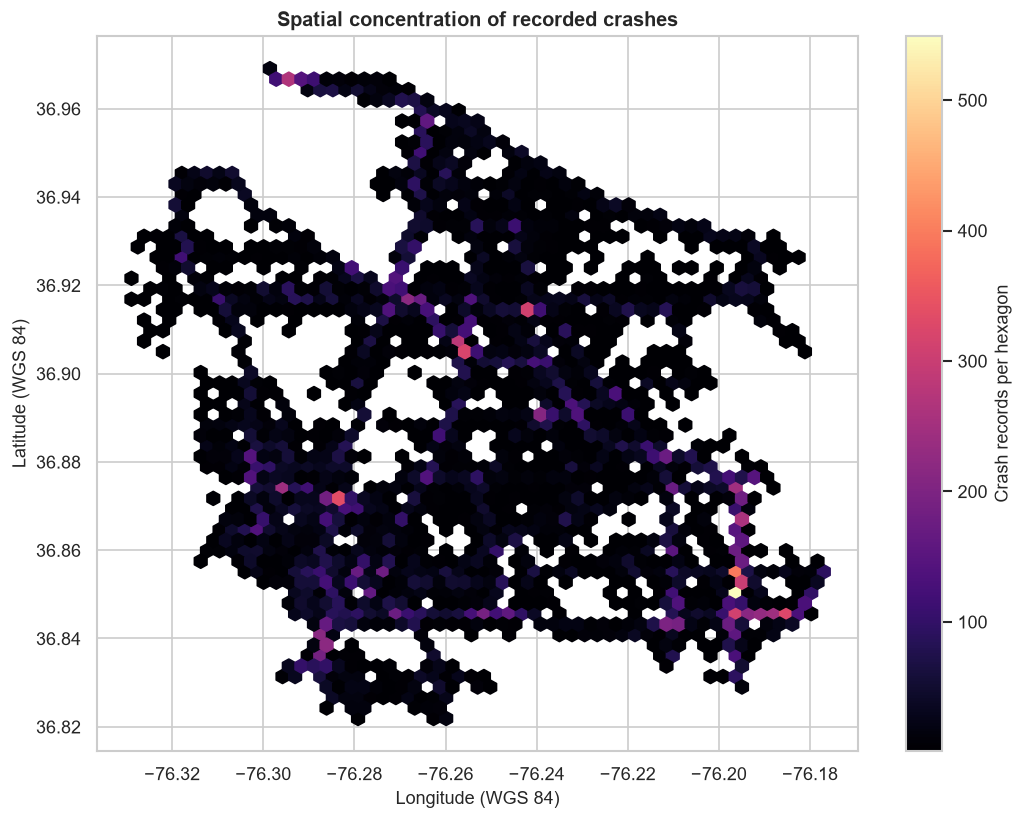

In [5]:
# 250 m grid = reproducible analytic proxy where authoritative intersection topology is unavailable.
# Uses a documented local metric approximation for screening, not survey-grade geometry.
geo_study["x_m"], geo_study["y_m"] = local_meters(geo_study.longitude.to_numpy(), geo_study.latitude.to_numpy())
geo_study["grid_x"] = np.floor(geo_study.x_m / 250).astype(int); geo_study["grid_y"] = np.floor(geo_study.y_m / 250).astype(int)
geo_study["location_id"] = "G" + geo_study.grid_x.astype(str) + "_" + geo_study.grid_y.astype(str)
location_burden = geo_study.groupby("location_id").agg(crashes=("Document Number","size"), fatalities=("fatalities","sum"), injuries=("injuries","sum"), pedestrian_crashes=("pedestrian_involved","sum"), bicycle_crashes=("bicycle_involved","sum"), latitude=("latitude","median"), longitude=("longitude","median"), street_example=("Route or Street Name","first")).sort_values("crashes",ascending=False)
display(location_burden.head(20))

fig, ax = plt.subplots(figsize=(9,7)); h=ax.hexbin(geo_study.longitude, geo_study.latitude, gridsize=55, mincnt=1, cmap="magma")
fig.colorbar(h,ax=ax,label="Crash records per hexagon"); ax.set(title="Spatial concentration of recorded crashes",xlabel="Longitude (WGS 84)",ylabel="Latitude (WGS 84)"); plt.tight_layout(); plt.show()

## 5. Pedestrian and bicycle involvement

Counts reflect records with an explicit affirmative flag. Severity comparisons use source-coded values and are outcomes among recorded crashes, not travel rates or probabilities.

,Group,Crashes,Percent of study records
0,Pedestrian involved,821,1.95%
1,Bicycle involved,339,0.81%
2,Any pedestrian or bicycle,1159,2.76%
3,No affirmative VRU flag,40845,97.24%


,crashes,fatalities,injuries,serious_injuries,injuries per 100 crashes
group,,,,,
No affirmative VRU flag,40845,145,20783,1644,50.88
Pedestrian or bicycle involved,1159,71,1347,279,116.22


,crashes,fatalities,injuries,pedestrian_crashes,bicycle_crashes,latitude,longitude,street_example
location_id,,,,,,,,
G26_-10,229,3,147,14,3,36.848794,-76.209991,400 N MILITARY HWY
G4_19,143,2,85,10,2,36.914775,-76.272808,100 BLK W LITTLE CREEK RD
G-7_7,61,0,24,9,0,36.887645,-76.302556,4700 HAMPTON BLVD
G-7_5,81,0,50,8,4,36.882330,-76.302260,4100 HAMPTON BOULEVARD
G-3_-10,50,0,23,8,1,36.848104,-76.291526,204 Granby Street
G15_19,304,0,215,7,6,36.914661,-76.241421,7800 CHESAPEAKE BLVD
G2_20,37,2,22,7,0,36.915448,-76.279232,7600 NEWPORT AVE
G-7_3,84,4,41,6,7,36.877916,-76.302000,3700 HAMPTON BLVD
G0_0,380,2,229,6,6,36.870720,-76.283283,2600 BLK OMOHUNDRO AVE


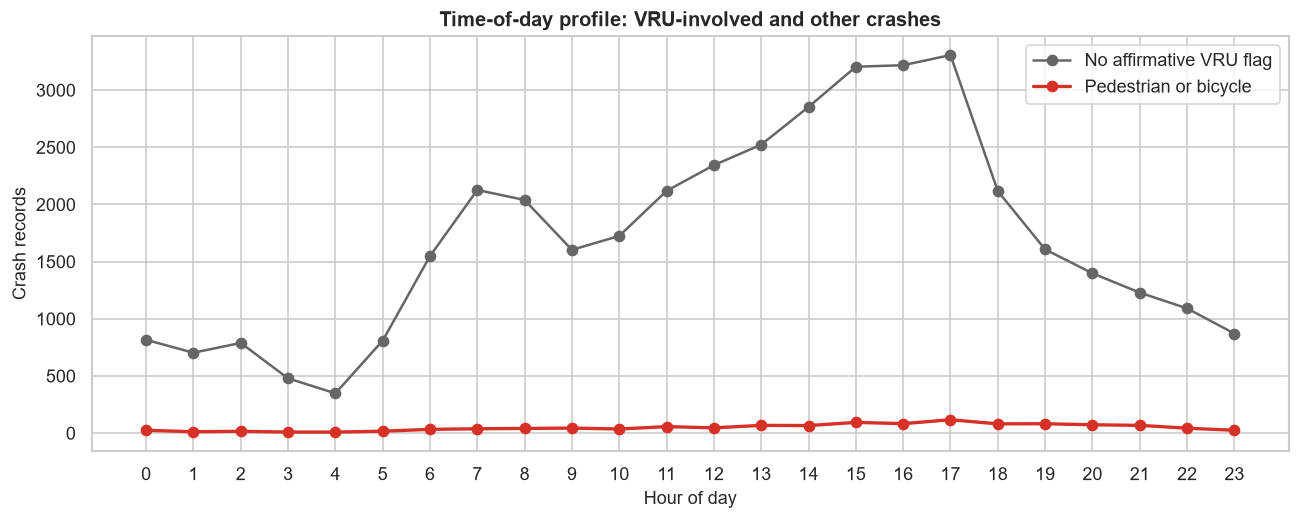

In [6]:
vru = pd.DataFrame({"Group":["Pedestrian involved","Bicycle involved","Any pedestrian or bicycle","No affirmative VRU flag"],"Crashes":[study.pedestrian_involved.sum(),study.bicycle_involved.sum(),study.vru_involved.sum(),(~study.vru_involved).sum()]})
vru["Percent of study records"] = 100*vru.Crashes/len(study); display(vru.style.format({"Percent of study records":"{:.2f}%"}))
comparison = study.assign(group=np.where(study.vru_involved,"Pedestrian or bicycle involved","No affirmative VRU flag")).groupby("group").agg(crashes=("Document Number","size"),fatalities=("fatalities","sum"),injuries=("injuries","sum"),serious_injuries=("serious_injuries","sum"))
comparison["injuries per 100 crashes"] = 100*comparison.injuries/comparison.crashes; display(comparison.round(2))
display(location_burden.query("pedestrian_crashes > 0 or bicycle_crashes > 0").sort_values(["pedestrian_crashes","bicycle_crashes","crashes"],ascending=False).head(20))

by_hour = study.groupby(["hour","vru_involved"]).size().unstack(fill_value=0).reindex(range(24),fill_value=0)
fig,ax=plt.subplots(figsize=(11,4.5)); ax.plot(by_hour.index,by_hour.get(False,0),marker="o",label="No affirmative VRU flag",color="#666666"); ax.plot(by_hour.index,by_hour.get(True,0),marker="o",label="Pedestrian or bicycle",color="#d73027",linewidth=2)
ax.set(title="Time-of-day profile: VRU-involved and other crashes",xlabel="Hour of day",ylabel="Crash records",xticks=range(24)); ax.legend(); plt.tight_layout(); plt.show()

## 6. Temporal patterns

These summaries use local clock times recorded by the source. They do not control for traffic volume, weather, daylight, school attendance, or reporting processes.

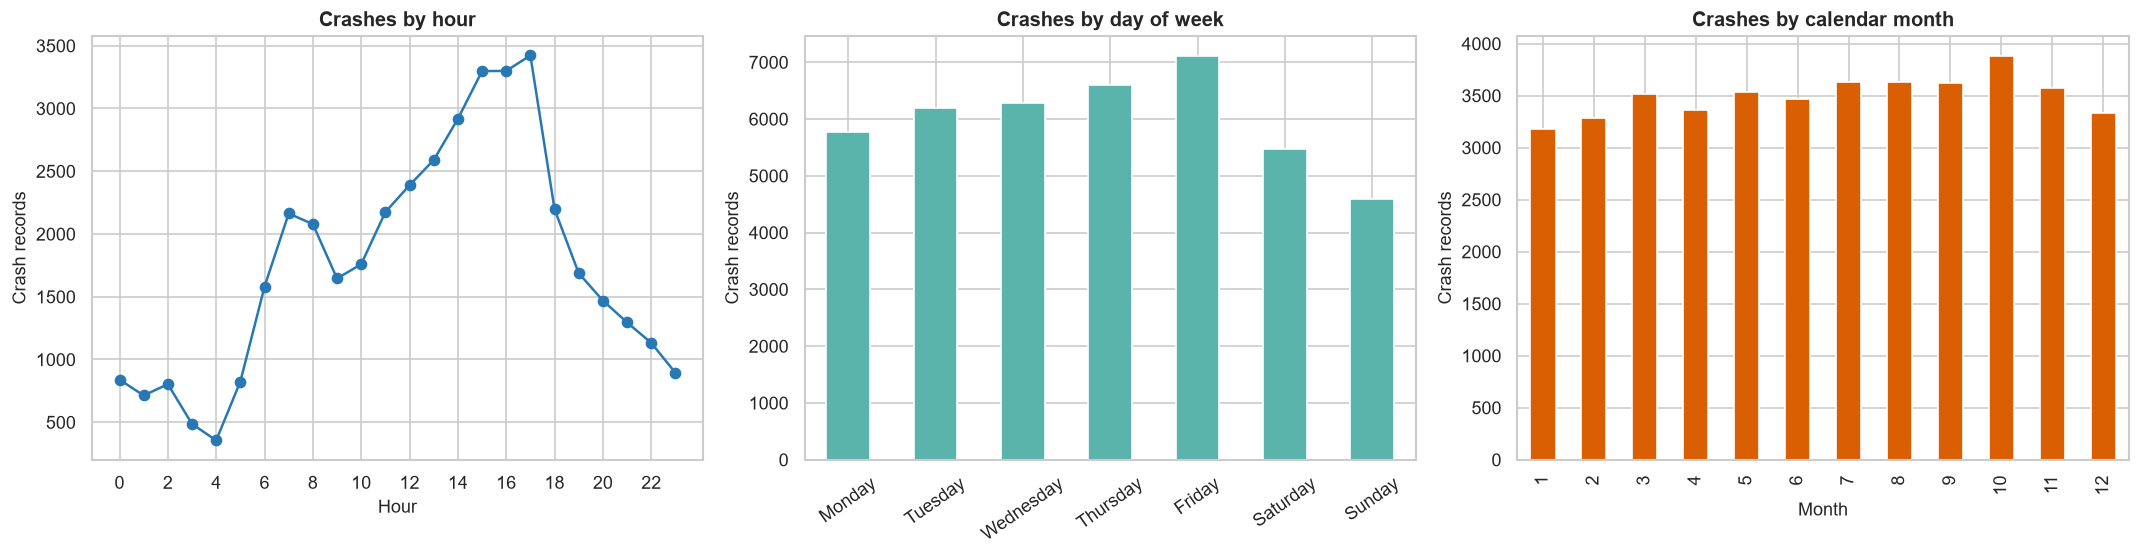

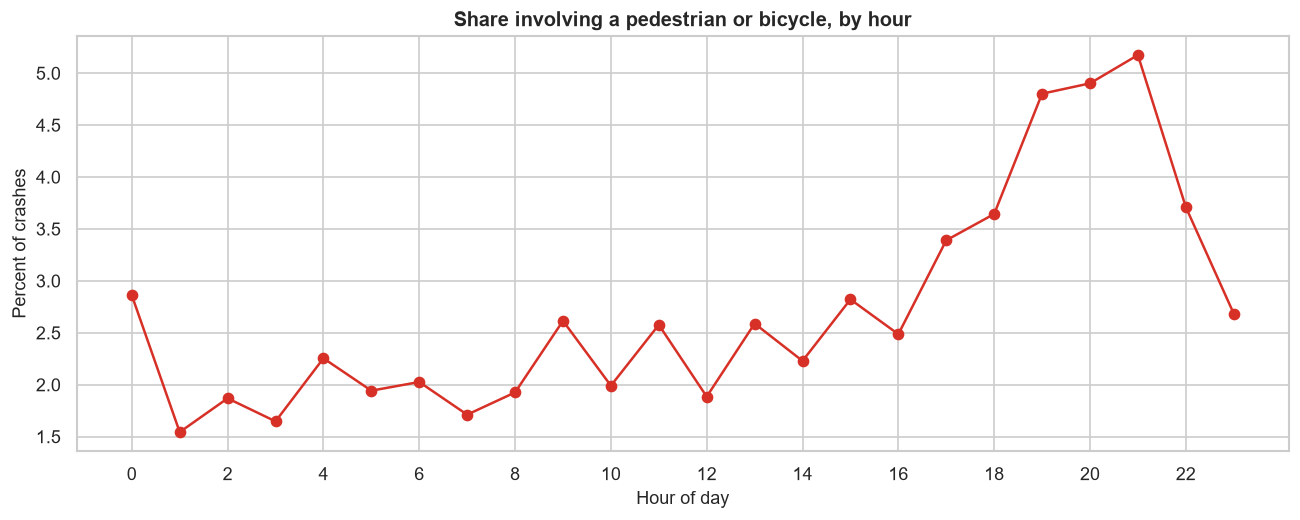

,crashes
is_weekend,
Weekday,31945
Weekend,10059


In [7]:
days=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig,axes=plt.subplots(1,3,figsize=(18,4.8))
study.hour.value_counts().reindex(range(24),fill_value=0).plot(ax=axes[0],marker="o",color="#2878b5"); axes[0].set(title="Crashes by hour",xlabel="Hour",ylabel="Crash records",xticks=range(0,24,2))
study.day_name.value_counts().reindex(days).plot.bar(ax=axes[1],color="#5ab4ac"); axes[1].set(title="Crashes by day of week",xlabel="",ylabel="Crash records"); axes[1].tick_params(axis="x",rotation=35)
study.month.value_counts().reindex(range(1,13),fill_value=0).plot.bar(ax=axes[2],color="#d95f02"); axes[2].set(title="Crashes by calendar month",xlabel="Month",ylabel="Crash records")
plt.tight_layout(); plt.show()

share = pd.crosstab(study.hour,study.vru_involved,normalize="index").reindex(range(24),fill_value=0)*100
fig,ax=plt.subplots(figsize=(11,4.5)); ax.plot(share.index,share.get(True,0),marker="o",color="#d73027")
ax.set(title="Share involving a pedestrian or bicycle, by hour",xlabel="Hour of day",ylabel="Percent of crashes",xticks=range(0,24,2)); plt.tight_layout(); plt.show()
display(study.groupby("is_weekend").size().rename(index={False:"Weekday",True:"Weekend"}).to_frame("crashes"))

## 7. Proximity to K–12 schools

Nationwide NCES files are filtered to Norfolk, Virginia. Straight-line distance uses EPSG:26918; it is not walking distance. The 0.25- and 0.5-mile buffers are descriptive thresholds, not legal school zones.

NCES-reported Norfolk K–12 facilities: 79


,NAME,school_type,STREET,CITY,STATE,latitude,longitude
53,Academy for Discovery at Lakewood,Public,1701 Alsace Ave,Norfolk,VA,36.883471,-76.262785
4,Azalea Gardens Middle,Public,7721 Azalea Garden Rd,Norfolk,VA,36.911400,-76.211000
63,BINA HIGH SCHOOL,Private,425 WASHINGTON PARK,NORFOLK,VA,36.866760,-76.291801
6,Bay View Elementary,Public,1434 Bay View Blvd,Norfolk,VA,36.935000,-76.236200
15,Berkley/Campostella Early Childhood Education ...,Public,1530 Cypress St,Norfolk,VA,36.828100,-76.264900
7,Blair Middle,Public,730 Spotswood Ave,Norfolk,VA,36.868400,-76.295700
5,Booker T Washington High,Public,1111 Park Ave,Norfolk,VA,36.853400,-76.266200
68,CHRIST THE KING CATHOLIC SCHOOL,Private,3401 TIDEWATER DR,NORFOLK,VA,36.881856,-76.262409
9,Camp Allen Elementary,Public,501 C Street,Norfolk,VA,36.928398,-76.296724
12,Chesterfield Elementary,Public,2915 Westminster Ave,Norfolk,VA,36.844500,-76.251300


,crashes,fatalities,injuries,ped_bike_crashes,percent spatial records
within_05_mi,,,,,
Beyond 0.5 mi,14698,64,7463,275,34.99
Within 0.5 mi,27306,152,14667,884,65.01


Within 0.25 mi: 11,544 (27.5%)


school_period,Other time,Weekday 7–9 AM or 2–4 PM,school-period share (%)
within_05_mi,,,
Beyond 0.5 mi,10299,4399,29.93
Within 0.5 mi,18922,8384,30.70


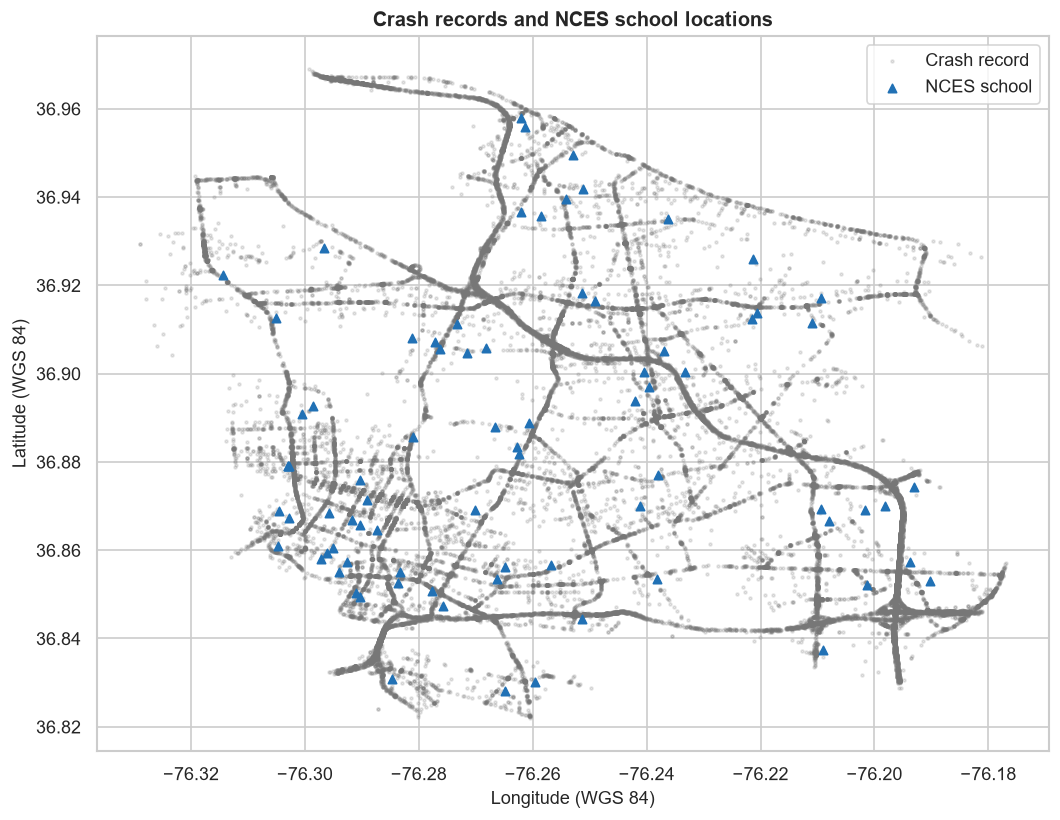

In [8]:
def filter_schools(df, kind):
    out=df.loc[(df.CITY.astype("string").str.strip().str.upper()=="NORFOLK")&(df.STATE.astype("string").str.strip().str.upper()=="VA")].copy()
    out["school_type"]=kind; out["latitude"]=pd.to_numeric(out.LAT,errors="coerce"); out["longitude"]=pd.to_numeric(out.LON,errors="coerce")
    return out.dropna(subset=["latitude","longitude"])
schools=pd.concat([filter_schools(public_raw,"Public"),filter_schools(private_raw,"Private")],ignore_index=True).drop_duplicates(subset=["NAME","latitude","longitude"])
print(f"NCES-reported Norfolk K–12 facilities: {len(schools):,}"); display(schools[["NAME","school_type","STREET","CITY","STATE","latitude","longitude"]].sort_values("NAME").head(20))
sx,sy=local_meters(schools.longitude.to_numpy(),schools.latitude.to_numpy()); dist, nearest=cKDTree(np.c_[sx,sy]).query(geo_study[["x_m","y_m"]].to_numpy())
geo_study["nearest_school_m"]=dist; geo_study["nearest_school"]=schools.iloc[nearest].NAME.to_numpy(); geo_study["within_025_mi"]=dist<=402.336; geo_study["within_05_mi"]=dist<=804.672
school_summary=geo_study.groupby("within_05_mi").agg(crashes=("Document Number","size"),fatalities=("fatalities","sum"),injuries=("injuries","sum"),ped_bike_crashes=("vru_involved","sum")).rename(index={True:"Within 0.5 mi",False:"Beyond 0.5 mi"})
school_summary["percent spatial records"]=100*school_summary.crashes/len(geo_study); display(school_summary.round(2)); print(f"Within 0.25 mi: {geo_study.within_025_mi.sum():,} ({100*geo_study.within_025_mi.mean():.1f}%)")

geo_study["school_period"]=(geo_study.dow.between(0,4)&geo_study.hour.between(7,9))|(geo_study.dow.between(0,4)&geo_study.hour.between(14,16))
school_time=pd.crosstab(geo_study.within_05_mi,geo_study.school_period).rename(index={True:"Within 0.5 mi",False:"Beyond 0.5 mi"},columns={True:"Weekday 7–9 AM or 2–4 PM",False:"Other time"}); school_time["school-period share (%)"]=100*school_time["Weekday 7–9 AM or 2–4 PM"]/school_time.sum(axis=1); display(school_time.round(2))

fig,ax=plt.subplots(figsize=(9,7)); ax.scatter(geo_study.longitude,geo_study.latitude,s=3,alpha=.18,color="#777777",label="Crash record"); ax.scatter(schools.longitude,schools.latitude,s=25,marker="^",color="#2171b5",label="NCES school"); ax.set(title="Crash records and NCES school locations",xlabel="Longitude (WGS 84)",ylabel="Latitude (WGS 84)"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Multivariate relationships and candidate review locations

This is a screening view, not a predictive model or production score. It highlights cells combining historical burden, confirmed VRU evidence, severity, and school proximity for further contextual review.

In [9]:
features=geo_study.groupby("location_id").agg(crash_count=("Document Number","size"),fatalities=("fatalities","sum"),injuries=("injuries","sum"),serious_injuries=("serious_injuries","sum"),ped_bike_crashes=("vru_involved","sum"),mean_school_distance_m=("nearest_school_m","mean"),within_05_mi_share=("within_05_mi","mean"),latitude=("latitude","median"),longitude=("longitude","median"),street_example=("Route or Street Name","first"))
display(features[["crash_count","fatalities","injuries","serious_injuries","ped_bike_crashes","mean_school_distance_m","within_05_mi_share"]].corr().round(2))
rank=lambda s:s.rank(pct=True,method="average")
features["screening_score"]=100*(.45*rank(features.crash_count)+.25*rank(features.ped_bike_crashes)+.15*rank(features.fatalities+features.serious_injuries)+.15*rank(-features.mean_school_distance_m))
display(features.sort_values("screening_score",ascending=False).head(20).round(2))

,crash_count,fatalities,injuries,serious_injuries,ped_bike_crashes,mean_school_distance_m,within_05_mi_share
crash_count,1.00,0.30,0.96,0.75,0.41,-0.03,0.03
fatalities,0.30,1.00,0.33,0.37,0.31,-0.05,0.03
injuries,0.96,0.33,1.00,0.80,0.49,-0.05,0.04
serious_injuries,0.75,0.37,0.80,1.00,0.45,-0.04,0.02
ped_bike_crashes,0.41,0.31,0.49,0.45,1.00,-0.15,0.14
mean_school_distance_m,-0.03,-0.05,-0.05,-0.04,-0.15,1.00,-0.80
within_05_mi_share,0.03,0.03,0.04,0.02,0.14,-0.80,1.00


,crash_count,fatalities,injuries,serious_injuries,ped_bike_crashes,mean_school_distance_m,within_05_mi_share,latitude,longitude,street_example,screening_score
location_id,,,,,,,,,,,
G8_7,142,1,91,7,5,235.82,1.0,36.89,-76.26,5400 TIDEWATER DR,96.29
G-7_4,161,0,69,6,3,172.34,1.0,36.88,-76.30,3900 BLK BOWDENS FERRY RD,95.66
G-7_3,84,4,41,3,13,155.97,1.0,36.88,-76.30,3700 HAMPTON BLVD,95.25
G4_19,143,2,85,7,12,362.14,1.0,36.91,-76.27,100 BLK W LITTLE CREEK RD,95.19
G5_-2,94,1,85,10,5,278.97,1.0,36.87,-76.27,2500 BLK TIDEWATER DR,94.37
G0_0,380,2,229,10,12,526.12,1.0,36.87,-76.28,2600 BLK OMOHUNDRO AVE,94.18
G11_20,128,1,82,3,6,294.44,1.0,36.92,-76.25,800 E LITTLE CREEK RD,94.08
G31_-7,384,0,205,10,2,333.53,1.0,36.85,-76.20,POPLAR HALL DR,93.79
G7_3,191,3,117,7,4,462.44,1.0,36.88,-76.26,3100 TIDEWATER DR,93.57


## 9. Ranking-methodology validation

The published pilot method combines historical burden, VRU evidence, time concentration, and school proximity. Exposure is disabled because the available ADT transfer is incomplete. Small-count cells, missing VRU coding, geographic exclusions, and unstable ranks need explicit review before any operational use.

In [10]:
checks=pd.DataFrame({"Input / check":["Valid-dated study records","Envelope-valid spatial records","Spatial exclusions","250 m grid cells","One-crash cells","Largest cell crash count","Any missing VRU flag","School reference facilities","Exposure denominator"],"Observed":[len(study),len(geo_study),len(study)-len(geo_study),len(features),(features.crash_count==1).sum(),features.crash_count.max(),crashes_raw[["Pedestrian Involved","Bicycle Involved"]].isna().any(axis=1).sum(),len(schools),"Disabled — transfer-limited ADT snapshot"],"Implication":["Descriptive historical burden only.","Eligible for grid and school-distance analysis.","Retain a row-level boundary-exclusion audit.","Analytic proxies, not intersections.","Percentile ranks can be unstable.","Audit for road geometry, duplicates, and coding.","Do not interpret blank as confirmed non-involvement.","2023–24 snapshot; recheck current facility status.","Do not present crash rates or exposure-adjusted ranks."]})
display(checks)

,Input / check,Observed,Implication
0,Valid-dated study records,42004,Descriptive historical burden only.
1,Envelope-valid spatial records,42004,Eligible for grid and school-distance analysis.
2,Spatial exclusions,0,Retain a row-level boundary-exclusion audit.
3,250 m grid cells,1614,"Analytic proxies, not intersections."
4,One-crash cells,262,Percentile ranks can be unstable.
5,Largest cell crash count,509,"Audit for road geometry, duplicates, and coding."
6,Any missing VRU flag,0,Do not interpret blank as confirmed non-involv...
7,School reference facilities,79,2023–24 snapshot; recheck current facility sta...
8,Exposure denominator,Disabled — transfer-limited ADT snapshot,Do not present crash rates or exposure-adjuste...


## 10. Summary, limitations, and next steps

### Modeling readiness

- **Reliable for descriptive work:** parsed timestamps, historical record counts, source-coded severity counts, and envelope-valid coordinates.
- **Preprocessing required:** approved-boundary validation, categorical normalization, duplicate review, explicit VRU missingness handling, and auditable fixed-grid assignment.
- **Use with limits:** school distance is proximity only; street names are not authoritative intersection identifiers; historical count is not risk.
- **Exclude from scoring:** exposure adjustment / crash-rate claims until a complete and validated denominator exists.

### Stakeholder transparency statement

Output locations should be described as places for **further safety review**. Historical crash concentration cannot establish fault, predict an incident, prove an intervention will work, or identify a person, vehicle, or community as a risk.

### Next actions

1. Reconcile every spatial exclusion against the approved Norfolk `covers` boundary and keep row-level lineage.
2. Obtain and cite the authoritative data dictionary; test coding changes by year, especially severity and VRU fields.
3. Validate candidate cells with Norfolk staff, roadway context, community input, and current school status.
4. Run temporal holdout and grid-size sensitivity tests before allocation decisions. The existing pilot release reported failed temporal-stability and grid-sensitivity gates, so the ranking remains exploratory.
5. Re-run and archive this notebook, input hashes, and outputs whenever either source snapshot changes.

In [11]:
# Optional interactive review map. Static charts above remain fully reproducible without folium.
if FOLIUM_AVAILABLE:
    sample=geo_study.sample(min(5000,len(geo_study)),random_state=config.get("random_seed",20260712))
    m=folium.Map(location=[geo_study.latitude.median(),geo_study.longitude.median()],zoom_start=11,tiles="CartoDB positron")
    HeatMap(sample[["latitude","longitude"]].values.tolist(),radius=8,blur=12,min_opacity=.25).add_to(m)
    for _, s in schools.iterrows(): folium.CircleMarker([s.latitude,s.longitude],radius=3,color="#2171b5",fill=True,tooltip=f"{s.NAME} ({s.school_type})").add_to(m)
    display(m)
else:
    print("Folium is not installed; install it only to render the optional interactive review map.")

Folium is not installed; install it only to render the optional interactive review map.
